In [3]:
# ============================================================
#   SMART WASTE CLASSIFICATION — FULL DATASET BUILDER
#   Scrapes images + generates text descriptions
#   Output: waste_dataset/ folders + dataset_metadata.csv
# ============================================================

# ── INSTALL DEPENDENCIES ─────────────────────────────────────
# Run this first in your terminal:
#   pip install icrawler pillow pandas

import os
import csv
import random
import shutil
from PIL import Image
import pandas as pd
from icrawler.builtin import BingImageCrawler

# ============================================================
# 1. CONFIGURATION
# ============================================================

OUTPUT_DIR       = "./waste_dataset"       # where images will be saved
METADATA_FILE    = "./dataset_metadata.csv"
IMAGES_PER_KEYWORD = 150                   # per keyword → ~450 per class total
MIN_IMAGE_SIZE   = (100, 100)              # discard images smaller than this

# ── Search keywords per class ────────────────────────────────
# 3 keywords × 150 images = ~450 images per class
CATEGORIES = {
    "glass": [
        "glass bottle waste garbage",
        "broken glass trash recycling",
        "glass jar discarded waste"
    ],
    "paper": [
        "paper waste garbage recycling",
        "crumpled newspaper trash",
        "white paper sheet discarded waste"
    ],
    "cardboard": [
        "cardboard box waste recycling",
        "flattened cardboard carton trash",
        "brown cardboard packaging garbage"
    ],
    "plastic": [
        "plastic bottle waste garbage",
        "plastic bag trash recycling",
        "used plastic container discarded"
    ],
    "metal": [
        "metal can waste garbage",
        "aluminum tin can trash recycling",
        "crushed steel can discarded waste"
    ],
    "trash": [
        "general household waste garbage",
        "mixed trash non recyclable waste",
        "random garbage waste bin"
    ]
}

# ── Text description templates per class ─────────────────────
# Used to generate diverse text for the NLP models (Members 4 & 5)
TEXT_TEMPLATES = {
    "glass": [
        "a glass bottle found in waste",
        "broken glass item for recycling",
        "glass container discarded as garbage",
        "clear glass waste material",
        "glass jar or bottle in trash bin",
        "recycled glass waste object",
        "shattered glass piece in garbage",
        "empty glass bottle thrown away"
    ],
    "paper": [
        "a crumpled piece of paper waste",
        "used newspaper or paper in trash",
        "white paper material discarded",
        "paper sheet for recycling bin",
        "old paper document thrown away",
        "paper waste item found in garbage",
        "recycled paper material object",
        "torn paper piece in waste bin"
    ],
    "cardboard": [
        "a flattened cardboard box in trash",
        "brown cardboard packaging waste",
        "used cardboard carton for recycling",
        "cardboard material discarded in bin",
        "empty cardboard box thrown away",
        "corrugated cardboard waste object",
        "old cardboard packaging garbage",
        "recycled cardboard box material"
    ],
    "plastic": [
        "a plastic bottle in garbage bin",
        "plastic waste item for recycling",
        "used plastic container discarded",
        "plastic packaging thrown in trash",
        "empty plastic bottle waste object",
        "plastic bag found in garbage",
        "discarded plastic material waste",
        "plastic waste recycling object"
    ],
    "metal": [
        "a crushed metal can in trash",
        "aluminum or steel waste item",
        "metal container for recycling bin",
        "used tin can discarded as waste",
        "empty metal can thrown away",
        "steel or aluminum waste object",
        "recycled metal can garbage item",
        "old metal container waste material"
    ],
    "trash": [
        "general household waste item",
        "mixed garbage non recyclable material",
        "non-recyclable waste object in bin",
        "general trash item discarded",
        "mixed waste garbage object",
        "household garbage thrown away",
        "random waste item in trash bin",
        "general waste material discarded"
    ]
}


# ============================================================
# 2. SCRAPE IMAGES
# ============================================================

def scrape_images():
    print("\n" + "="*60)
    print("  STEP 1: SCRAPING IMAGES")
    print("="*60)

    for class_name, keywords in CATEGORIES.items():
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_dir, exist_ok=True)

        for keyword in keywords:
            print(f"\n  → Scraping '{keyword}' into class '{class_name}'...")

            crawler = BingImageCrawler(
                storage={"root_dir": class_dir},
                feeder_threads=2,
                parser_threads=2,
                downloader_threads=4,
                log_level=40  # suppress noisy logs (ERROR level only)
            )
            crawler.crawl(
                keyword=keyword,
                max_num=IMAGES_PER_KEYWORD,
                min_size=MIN_IMAGE_SIZE,
                file_idx_offset="auto"   # never overwrite existing files
            )

    print("\n  ✅ Scraping complete!\n")


# ============================================================
# 3. CLEAN DATASET (remove corrupted / too small images)
# ============================================================

def clean_dataset():
    print("="*60)
    print("  STEP 2: CLEANING DATASET")
    print("="*60)

    total_removed = 0

    for class_name in os.listdir(OUTPUT_DIR):
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        if not os.path.isdir(class_dir):
            continue

        removed = 0
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()                        # check corruption

                # Re-open after verify (verify closes the file)
                with Image.open(fpath) as img:
                    w, h = img.size
                    if w < MIN_IMAGE_SIZE[0] or h < MIN_IMAGE_SIZE[1]:
                        os.remove(fpath)
                        removed += 1

            except Exception:
                os.remove(fpath)                        # corrupted → delete
                removed += 1

        print(f"  [{class_name}] removed {removed} bad images")
        total_removed += removed

    print(f"\n  ✅ Cleaning done. Total removed: {total_removed}\n")


# ============================================================
# 4. BUILD METADATA CSV (image path + text description + label)
# ============================================================

def build_metadata():
    print("="*60)
    print("  STEP 3: BUILDING METADATA (image + text + label)")
    print("="*60)

    records = []

    for class_name in os.listdir(OUTPUT_DIR):
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        if not os.path.isdir(class_dir):
            continue

        image_files = [
            f for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]

        for fname in image_files:
            rel_path = os.path.join("waste_dataset", class_name, fname)

            # Pick a random text description from the templates
            text_desc = random.choice(TEXT_TEMPLATES[class_name])

            records.append({
                "image_path":       rel_path,
                "text_description": text_desc,
                "label":            class_name
            })

    # Save to CSV
    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
    df.to_csv(METADATA_FILE, index=False)

    print(f"  ✅ Saved {len(records)} records to '{METADATA_FILE}'\n")
    return df


# ============================================================
# 5. PRINT FINAL SUMMARY
# ============================================================

def print_summary(df):
    print("="*60)
    print("  FINAL DATASET SUMMARY")
    print("="*60)

    counts = df["label"].value_counts().sort_index()
    max_count = counts.max()

    for label, count in counts.items():
        bar = "█" * int((count / max_count) * 40)
        print(f"  {label:<12} {bar:<42} {count}")

    print(f"\n  Total images : {len(df)}")
    print(f"  Classes      : {df['label'].nunique()}")
    print(f"  CSV saved to : {METADATA_FILE}")
    print("\n  Sample rows from CSV:")
    print(df.head(6).to_string(index=False))
    print("="*60)
    print("\n  ✅ Dataset ready! Hand 'waste_dataset/' and")
    print("     'dataset_metadata.csv' to Member 1.\n")


# ============================================================
# 6. RUN EVERYTHING
# ============================================================

if __name__ == "__main__":
    scrape_images()     # Step 1 — download images from Bing
    clean_dataset()     # Step 2 — remove bad/corrupt images
    df = build_metadata()   # Step 3 — build CSV with text + labels
    print_summary(df)   # Step 4 — show final counts

2026-04-25 17:03:03,729 - INFO - numexpr.utils - Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-04-25 17:03:03,730 - INFO - numexpr.utils - NumExpr defaulting to 16 threads.
2026-04-25 17:03:05,486 - INFO - icrawler.crawler - start crawling...
2026-04-25 17:03:05,486 - INFO - icrawler.crawler - starting 2 feeder threads...
2026-04-25 17:03:05,488 - INFO - feeder - thread feeder-001 exit
2026-04-25 17:03:05,489 - INFO - feeder - thread feeder-002 exit
2026-04-25 17:03:05,492 - INFO - icrawler.crawler - starting 2 parser threads...
2026-04-25 17:03:05,496 - INFO - icrawler.crawler - starting 4 downloader threads...



  STEP 1: SCRAPING IMAGES

  → Scraping 'glass bottle waste garbage' into class 'glass'...


2026-04-25 17:03:06,829 - INFO - parser - parsing result page https://www.bing.com/images/async?q=glass bottle waste garbage&first=0
2026-04-25 17:03:06,996 - INFO - parser - parsing result page https://www.bing.com/images/async?q=glass bottle waste garbage&first=20
2026-04-25 17:03:07,816 - INFO - downloader - image #1	https://c8.alamy.com/comp/2WBGG68/glass-bottle-garbage-icon-cartoon-vector-recycle-glass-sorting-home-waste-2WBGG68.jpg
2026-04-25 17:03:08,111 - INFO - downloader - image #2	https://thumbs.dreamstime.com/z/glass-waste-many-isolated-white-background-pile-glass-garbage-recycling-waste-bottle-glass-rubbish-recycle-glass-179523576.jpg
2026-04-25 17:03:08,355 - INFO - downloader - image #3	https://c8.alamy.com/comp/2ATF1W0/glass-bottle-trash-waste-2ATF1W0.jpg
2026-04-25 17:03:09,283 - INFO - downloader - image #4	https://cdn.pixabay.com/photo/2022/04/24/17/12/glass-7154092_640.jpg
2026-04-25 17:03:09,474 - INFO - downloader - image #5	https://c8.alamy.com/comp/2STC6MT/glass


  → Scraping 'broken glass trash recycling' into class 'glass'...


2026-04-25 17:04:17,605 - INFO - parser - parsing result page https://www.bing.com/images/async?q=broken glass trash recycling&first=0
2026-04-25 17:04:17,805 - INFO - parser - parsing result page https://www.bing.com/images/async?q=broken glass trash recycling&first=20
2026-04-25 17:04:18,831 - INFO - downloader - image #1	https://static.vecteezy.com/system/resources/previews/054/429/268/large_2x/broken-glass-and-recycling-bins-photo.jpg
2026-04-25 17:04:18,835 - INFO - downloader - image #2	https://as2.ftcdn.net/v2/jpg/09/34/55/59/1000_F_934555925_ZXCS0vOz0VyYl3CJxW1ujgtVVxqpiqTu.jpg
2026-04-25 17:04:18,837 - INFO - downloader - image #3	https://c8.alamy.com/comp/MHMJ80/recycling-broken-glass-MHMJ80.jpg
2026-04-25 17:04:19,114 - INFO - downloader - image #4	https://as2.ftcdn.net/v2/jpg/08/27/47/39/1000_F_827473995_Ymye72mvQBZJP5SoTbOOD8T6HD7hndcJ.jpg
2026-04-25 17:04:19,710 - INFO - downloader - image #5	https://img.freepik.com/premium-photo/broken-glass-recycling-container_419341-63

...


  → Scraping 'mixed trash non recyclable waste' into class 'trash'...


2026-04-25 17:16:52,522 - INFO - parser - parsing result page https://www.bing.com/images/async?q=mixed trash non recyclable waste&first=20
2026-04-25 17:16:52,528 - INFO - parser - parsing result page https://www.bing.com/images/async?q=mixed trash non recyclable waste&first=0
2026-04-25 17:16:54,195 - INFO - downloader - image #1	https://c8.alamy.com/comp/A8F1H1/a-mixture-of-non-recyclable-rubbish-and-waste-A8F1H1.jpg
2026-04-25 17:16:54,828 - INFO - downloader - image #2	https://www.shutterstock.com/shutterstock/photos/1441631591/display_1500/stock-photo-london-uk-june-close-up-of-a-bin-full-with-mixed-trash-1441631591.jpg
2026-04-25 17:16:55,592 - INFO - downloader - image #3	https://kimbriki.com.au/wp-content/uploads/2024/03/Arrow-Mixed-Waste-5-Banner-right-600x236.jpg
2026-04-25 17:16:56,082 - INFO - downloader - image #4	https://www.shutterstock.com/shutterstock/photos/1762379924/display_1500/stock-photo-garbage-dump-overcrowded-dumpsters-mixed-waste-a-lot-of-garbage-1762379924.


  → Scraping 'random garbage waste bin' into class 'trash'...


2026-04-25 17:17:37,682 - INFO - parser - parsing result page https://www.bing.com/images/async?q=random garbage waste bin&first=0
2026-04-25 17:17:37,692 - INFO - parser - parsing result page https://www.bing.com/images/async?q=random garbage waste bin&first=20
2026-04-25 17:17:39,296 - INFO - downloader - image #1	https://c8.alamy.com/comp/2M57NEP/waste-management-system-in-public-perspective-huge-rubbish-bin-for-garbage-2M57NEP.jpg
2026-04-25 17:17:39,379 - INFO - downloader - image #2	https://t4.ftcdn.net/jpg/01/65/90/65/360_F_165906568_pjEcmkF8Nh0cBbH3W2q7kKrqz1SmksyP.jpg
2026-04-25 17:17:39,872 - INFO - downloader - image #3	https://img.freepik.com/premium-photo/garbage-bin_631068-4105.jpg
2026-04-25 17:17:41,159 - INFO - downloader - image #4	https://iirorwxhiqjqjn5p.ldycdn.com/cloud/lkBpoKirjpSRqiioqkjpjq/HTB1l2dmbsrrK1RjSspaq6AREXXaw2.jpg
2026-04-25 17:17:41,254 - INFO - downloader - image #5	https://cdn.renderhub.com/mightyalexone/garbage-bin/garbage-bin-02.jpg
2026-04-25 17:


  ✅ Scraping complete!

  STEP 2: CLEANING DATASET
  [cardboard] removed 0 bad images
  [glass] removed 0 bad images
  [metal] removed 0 bad images
  [paper] removed 0 bad images
  [plastic] removed 0 bad images
  [trash] removed 0 bad images

  ✅ Cleaning done. Total removed: 0

  STEP 3: BUILDING METADATA (image + text + label)
  ✅ Saved 1132 records to './dataset_metadata.csv'

  FINAL DATASET SUMMARY
  cardboard    ████████████████████████████████████       199
  glass        ███████████████████████████████████        192
  metal        ████████████████████████████████████████   216
  paper        █████████████████████████████████          181
  plastic      ████████████████████████████████████       198
  trash        ███████████████████████████                146

  Total images : 1132
  Classes      : 6
  CSV saved to : ./dataset_metadata.csv

  Sample rows from CSV:
                        image_path                 text_description     label
    waste_dataset\paper\000177.jpg

In [1]:
# ============================================================
#   SCRAPER 1 — Requests + BeautifulSoup
#   Scrapes Bing Images for each waste category
#   Output: waste_dataset/ folders
# ============================================================

# pip install requests beautifulsoup4 pillow

import os
import json
import time
import random
import requests
from bs4 import BeautifulSoup
from PIL import Image
from io import BytesIO

# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_DIR       = "./waste_dataset"
IMAGES_PER_QUERY = 150          # images per keyword
MIN_SIZE         = (100, 100)   # discard images smaller than this
DELAY_BETWEEN_REQUESTS = 1.5    # seconds (be polite, avoid getting blocked)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
}

CATEGORIES = {
    "glass": [
        "glass bottle waste garbage",
        "broken glass trash recycling",
        "glass jar discarded waste"
    ],
    "paper": [
        "paper waste garbage recycling",
        "crumpled newspaper trash",
        "white paper sheet discarded waste"
    ],
    "cardboard": [
        "cardboard box waste recycling",
        "flattened cardboard carton trash",
        "brown cardboard packaging garbage"
    ],
    "plastic": [
        "plastic bottle waste garbage",
        "plastic bag trash recycling",
        "used plastic container discarded"
    ],
    "metal": [
        "metal can waste garbage",
        "aluminum tin can trash recycling",
        "crushed steel can discarded waste"
    ],
    "trash": [
        "general household waste garbage",
        "mixed trash non recyclable waste",
        "random garbage waste bin"
    ]
}


# ============================================================
# STEP 1 — GET IMAGE URLs FROM BING
# ============================================================

def get_bing_image_urls(query: str, max_images: int = 150) -> list:
    """
    Scrape Bing Image Search results for a given query.
    Bing embeds image metadata as JSON inside <a class='iusc'> tags.
    We parse that JSON to extract the real image URL (murl field).
    """
    urls = []
    offset = 0
    session = requests.Session()
    session.headers.update(HEADERS)

    print(f"    Searching Bing for: '{query}'")

    while len(urls) < max_images:
        # Bing paginates using 'first' offset parameter
        params = {
            "q":     query,
            "count": 35,
            "first": offset,
            "FORM":  "IBASEP"
        }

        try:
            response = session.get(
                "https://www.bing.com/images/search",
                params=params,
                timeout=10
            )
            response.raise_for_status()
        except requests.RequestException as e:
            print(f"    ⚠️  Request failed: {e}")
            break

        soup = BeautifulSoup(response.text, "html.parser")

        # Each image result is inside <a class="iusc"> with a JSON 'm' attribute
        # The JSON contains: murl (full image url), turl (thumbnail), desc, etc.
        items = soup.find_all("a", class_="iusc")

        if not items:
            print(f"    ⚠️  No more results at offset {offset}")
            break

        for item in items:
            raw = item.get("m")
            if not raw:
                continue
            try:
                data = json.loads(raw)
                img_url = data.get("murl")
                if img_url and img_url.startswith("http"):
                    urls.append(img_url)
            except json.JSONDecodeError:
                continue

        offset += 35
        time.sleep(DELAY_BETWEEN_REQUESTS)  # avoid rate-limiting

    print(f"    Found {len(urls)} URLs")
    return urls[:max_images]


# ============================================================
# STEP 2 — DOWNLOAD & VALIDATE IMAGES
# ============================================================

def download_image(url: str, save_path: str) -> bool:
    """
    Download one image from URL.
    Validates it is a real image and meets minimum size.
    Returns True if saved successfully.
    """
    try:
        response = requests.get(url, timeout=8, headers=HEADERS)
        response.raise_for_status()

        # Validate it's actually an image using Pillow
        img = Image.open(BytesIO(response.content))
        img.verify()

        # Re-open after verify (verify() closes the file handle)
        img = Image.open(BytesIO(response.content))

        # Check minimum size
        if img.size[0] < MIN_SIZE[0] or img.size[1] < MIN_SIZE[1]:
            return False

        # Convert to RGB (some PNGs are RGBA, some are P mode)
        img = img.convert("RGB")
        img.save(save_path, "JPEG", quality=90)
        return True

    except Exception:
        return False


# ============================================================
# STEP 3 — SCRAPE ALL CATEGORIES
# ============================================================

def scrape_all():
    print("\n" + "="*60)
    print("  SCRAPER 1: Requests + BeautifulSoup")
    print("="*60 + "\n")

    for class_name, keywords in CATEGORIES.items():
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_dir, exist_ok=True)

        print(f"\n  ── Class: {class_name.upper()} ──")

        for keyword in keywords:
            # Get image URLs from Bing
            urls = get_bing_image_urls(keyword, max_images=IMAGES_PER_QUERY)

            # Count existing files to continue numbering from there
            existing = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            saved = 0
            for i, url in enumerate(urls):
                filename  = f"{existing + saved + 1:06d}.jpg"
                save_path = os.path.join(class_dir, filename)

                success = download_image(url, save_path)
                if success:
                    saved += 1

                # Small random delay between downloads
                time.sleep(random.uniform(0.3, 0.8))

            print(f"    ✅ Saved {saved}/{len(urls)} images for '{keyword}'")

        total = len(os.listdir(class_dir))
        print(f"  Total in '{class_name}': {total} images")

    print("\n" + "="*60)
    print("  ✅ BS4 Scraping complete!")
    print(f"  Images saved to: {os.path.abspath(OUTPUT_DIR)}")
    print("="*60 + "\n")


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    scrape_all()
    print("Next step: run  build_metadata.py  to clean + build CSV")


  SCRAPER 1: Requests + BeautifulSoup


  ── Class: GLASS ──
    Searching Bing for: 'glass bottle waste garbage'
    Found 151 URLs


c:\Users\JOHN\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


    ✅ Saved 122/150 images for 'glass bottle waste garbage'
    Searching Bing for: 'broken glass trash recycling'
    Found 170 URLs
    ✅ Saved 150/150 images for 'broken glass trash recycling'
    Searching Bing for: 'glass jar discarded waste'
    Found 167 URLs
    ✅ Saved 138/150 images for 'glass jar discarded waste'
  Total in 'glass': 410 images

  ── Class: PAPER ──
    Searching Bing for: 'paper waste garbage recycling'
    Found 158 URLs
    ✅ Saved 140/150 images for 'paper waste garbage recycling'
    Searching Bing for: 'crumpled newspaper trash'
    Found 175 URLs
    ✅ Saved 144/150 images for 'crumpled newspaper trash'
    Searching Bing for: 'white paper sheet discarded waste'
    Found 158 URLs
    ✅ Saved 146/150 images for 'white paper sheet discarded waste'
  Total in 'paper': 430 images

  ── Class: CARDBOARD ──
    Searching Bing for: 'cardboard box waste recycling'
    Found 151 URLs
    ✅ Saved 142/150 images for 'cardboard box waste recycling'
    Searching 


  STEP 1: CLEANING DATASET
  [cardboard   ] kept:  429  |  removed:   0
  [glass       ] kept:  410  |  removed:   0
  [metal       ] kept:  433  |  removed:   0
  [paper       ] kept:  430  |  removed:   0
  [plastic     ] kept:  395  |  removed:   0
  [trash       ] kept:  418  |  removed:   0

  Total removed: 0 bad images

  STEP 2: BUILDING dataset_metadata.csv
  Saved 2515 records → ./dataset_metadata.csv

  STEP 3: CLASS DISTRIBUTION
  cardboard    ███████████████████████████████████████    429
  glass        █████████████████████████████████████      410
  metal        ████████████████████████████████████████   433
  paper        ███████████████████████████████████████    430
  plastic      ████████████████████████████████████       395
  trash        ██████████████████████████████████████     418

  Total images : 2515
  Classes      : 6



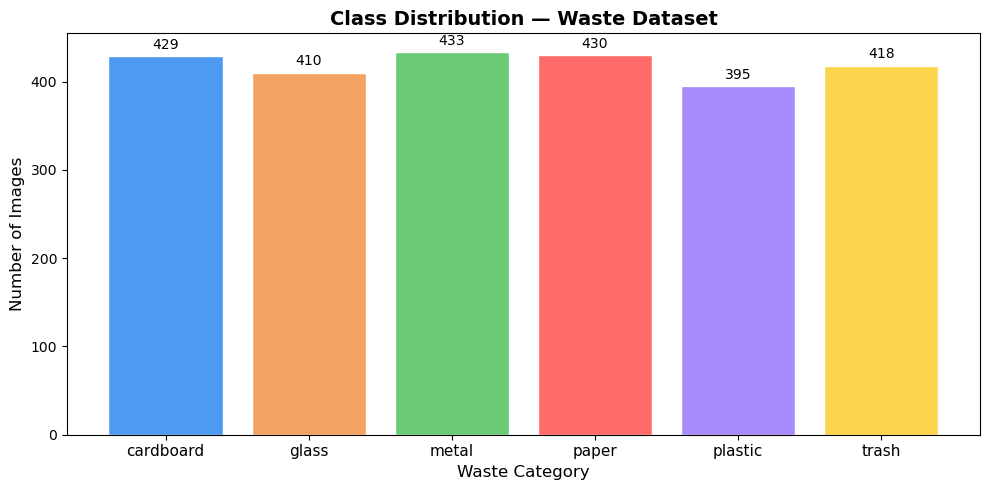

  Chart saved → class_distribution.png

  SAMPLE ROWS FROM dataset_metadata.csv
                        image_path                      text_description     label
    waste_dataset\trash\000113.jpg      general waste material discarded     trash
    waste_dataset\glass\000032.jpg     a glass bottle found in waste bin     glass
    waste_dataset\trash\000132.jpg          general trash item discarded     trash
    waste_dataset\trash\000313.jpg      mixed waste garbage object found     trash
  waste_dataset\plastic\000229.jpg plastic packaging thrown in trash bin   plastic
waste_dataset\cardboard\000080.jpg   used cardboard carton for recycling cardboard


  TEAM HANDOFF

  ┌─────────────┬─────────────────────────────────────────┐
  │ Member      │ What to use                             │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 1    │ waste_dataset/ + dataset_metadata.csv   │
  │             │ → run your preprocessing pipeline       │
  ├─────────────┼────

In [2]:
# ============================================================
#   BUILD METADATA — Shared for all team members
#   Run this AFTER either scraper finishes
#   Input:  waste_dataset/ folders
#   Output: waste_dataset/ (cleaned) + dataset_metadata.csv
# ============================================================

# pip install pillow pandas matplotlib

import os
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIGURATION
# ============================================================

OUTPUT_DIR    = "./waste_dataset"
METADATA_FILE = "./dataset_metadata.csv"
MIN_SIZE      = (100, 100)

# ── Text description templates per class ─────────────────────
# Used by Members 4 & 5 for NLP models (BoW, RNN, LSTM)
TEXT_TEMPLATES = {
    "glass": [
        "a glass bottle found in waste bin",
        "broken glass item for recycling",
        "glass container discarded as garbage",
        "clear glass waste material in trash",
        "glass jar or bottle thrown away",
        "recycled glass waste object found",
        "shattered glass piece in garbage bin",
        "empty glass bottle discarded waste"
    ],
    "paper": [
        "a crumpled piece of paper waste",
        "used newspaper or paper in trash bin",
        "white paper material discarded waste",
        "paper sheet thrown in recycling bin",
        "old paper document thrown away",
        "paper waste item found in garbage",
        "recycled paper material waste object",
        "torn paper piece in waste bin"
    ],
    "cardboard": [
        "a flattened cardboard box in trash",
        "brown cardboard packaging waste material",
        "used cardboard carton for recycling",
        "cardboard material discarded in bin",
        "empty cardboard box thrown away",
        "corrugated cardboard waste object found",
        "old cardboard packaging garbage item",
        "recycled cardboard box material waste"
    ],
    "plastic": [
        "a plastic bottle in garbage bin",
        "plastic waste item for recycling",
        "used plastic container discarded waste",
        "plastic packaging thrown in trash bin",
        "empty plastic bottle waste object",
        "plastic bag found in garbage waste",
        "discarded plastic material waste item",
        "plastic waste recycling object found"
    ],
    "metal": [
        "a crushed metal can in trash",
        "aluminum or steel waste item found",
        "metal container for recycling bin",
        "used tin can discarded as waste",
        "empty metal can thrown away",
        "steel or aluminum waste object",
        "recycled metal can garbage item found",
        "old metal container waste material"
    ],
    "trash": [
        "general household waste item found",
        "mixed garbage non recyclable material",
        "non recyclable waste object in bin",
        "general trash item discarded",
        "mixed waste garbage object found",
        "household garbage thrown away",
        "random waste item in trash bin",
        "general waste material discarded"
    ]
}


# ============================================================
# STEP 1 — CLEAN DATASET
# ============================================================

def clean_dataset():
    print("\n" + "="*60)
    print("  STEP 1: CLEANING DATASET")
    print("="*60)

    total_removed = 0

    for class_name in sorted(os.listdir(OUTPUT_DIR)):
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        if not os.path.isdir(class_dir):
            continue

        removed   = 0
        kept      = 0

        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)

            # Only process image files
            if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp")):
                os.remove(fpath)
                removed += 1
                continue

            try:
                with Image.open(fpath) as img:
                    img.verify()   # raises if corrupted

                with Image.open(fpath) as img:
                    w, h = img.size
                    if w < MIN_SIZE[0] or h < MIN_SIZE[1]:
                        raise ValueError("Too small")

                kept += 1

            except Exception:
                os.remove(fpath)
                removed += 1

        print(f"  [{class_name:<12}] kept: {kept:>4}  |  removed: {removed:>3}")
        total_removed += removed

    print(f"\n  Total removed: {total_removed} bad images\n")


# ============================================================
# STEP 2 — BUILD METADATA CSV
# ============================================================

def build_metadata():
    print("="*60)
    print("  STEP 2: BUILDING dataset_metadata.csv")
    print("="*60)

    records = []

    for class_name in sorted(os.listdir(OUTPUT_DIR)):
        class_dir = os.path.join(OUTPUT_DIR, class_name)
        if not os.path.isdir(class_dir):
            continue

        image_files = sorted([
            f for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        for fname in image_files:
            rel_path  = os.path.join("waste_dataset", class_name, fname)
            text_desc = random.choice(TEXT_TEMPLATES[class_name])

            records.append({
                "image_path":       rel_path,
                "text_description": text_desc,
                "label":            class_name
            })

    # Shuffle the full dataset
    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_csv(METADATA_FILE, index=False)

    print(f"  Saved {len(df)} records → {METADATA_FILE}\n")
    return df


# ============================================================
# STEP 3 — VISUALIZE CLASS DISTRIBUTION
# ============================================================

def visualize_distribution(df):
    print("="*60)
    print("  STEP 3: CLASS DISTRIBUTION")
    print("="*60)

    counts    = df["label"].value_counts().sort_index()
    max_count = counts.max()

    # Terminal bar chart
    for label, count in counts.items():
        bar     = "█" * int((count / max_count) * 40)
        warning = "  ⚠️  low!" if count < 300 else ""
        print(f"  {label:<12} {bar:<42} {count}{warning}")

    total = len(df)
    print(f"\n  Total images : {total}")
    print(f"  Classes      : {df['label'].nunique()}\n")

    # Save PNG chart
    colors = ["#4E9AF1","#F4A261","#6BCB77","#FF6B6B","#A78BFA","#FCD34D"]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor="white")
    plt.title("Class Distribution — Waste Dataset", fontsize=14, fontweight="bold")
    plt.xlabel("Waste Category",  fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(fontsize=11)

    for bar, count in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontsize=10
        )

    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150)
    plt.show()
    print("  Chart saved → class_distribution.png\n")


# ============================================================
# STEP 4 — PRINT SAMPLE ROWS
# ============================================================

def print_sample(df):
    print("="*60)
    print("  SAMPLE ROWS FROM dataset_metadata.csv")
    print("="*60)
    print(df.sample(6, random_state=1).to_string(index=False))
    print("\n")


# ============================================================
# STEP 5 — HANDOFF SUMMARY FOR TEAM
# ============================================================

def print_handoff():
    print("="*60)
    print("  TEAM HANDOFF")
    print("="*60)
    print("""
  ┌─────────────┬─────────────────────────────────────────┐
  │ Member      │ What to use                             │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 1    │ waste_dataset/ + dataset_metadata.csv   │
  │             │ → run your preprocessing pipeline       │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 2    │ Preprocessed IMAGES from Member 1       │
  │             │ (CNN + MobileNet)                       │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 3    │ Preprocessed IMAGES from Member 1       │
  │             │ (ResNet-50)                             │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 4    │ TEXT column from dataset_metadata.csv   │
  │             │ (BoW + RNN models)                      │
  ├─────────────┼─────────────────────────────────────────┤
  │ Member 5    │ TEXT column from dataset_metadata.csv   │
  │             │ (LSTM + final report)                   │
  └─────────────┴─────────────────────────────────────────┘
    """)


# ============================================================
# RUN ALL STEPS
# ============================================================

if __name__ == "__main__":
    clean_dataset()
    df = build_metadata()
    visualize_distribution(df)
    print_sample(df)
    print_handoff()